# Task 3 - Random Forest

Uses TF-IDF vectorization and uses a random forest classifier in order to predict the computer science subcategory from ArXiv paper abstracts.

(Hyper parameters for TF-IDF) 5000 vocabulary size and an LSA dimension size of 500

(Hyper parameters for Random Forest Trees) 500 trees with no maximum depth, features are considered at each split with 'sqrt' with a minimum sample number of 2 at a leaf node. The random forest handles the class imbalances automatically.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import re
import time

## 2. Loading Data

In [2]:
train_df = pd.read_csv('train.csv', sep='\t')
test_df  = pd.read_csv('test.csv', sep='\t')
taxonomy = pd.read_csv('label_taxonomy.csv', sep='\t')

id_to_cat = dict(zip(taxonomy['label_id'], taxonomy['category']))

print(f'Train samples : {len(train_df):,}')
print(f'Test  samples : {len(test_df):,}')
print(f'Number of classes: {train_df["label_id"].nunique()}')
train_df.head(3)

Train samples : 139,156
Test  samples : 34,790
Number of classes: 39


,id,abstract,label_id
0,95829,Project-based learning plays a crucial role in...,14
1,73195,Edge computing is a distributed computing pa...,10
2,22319,"In today's computing environment, where Arti...",3


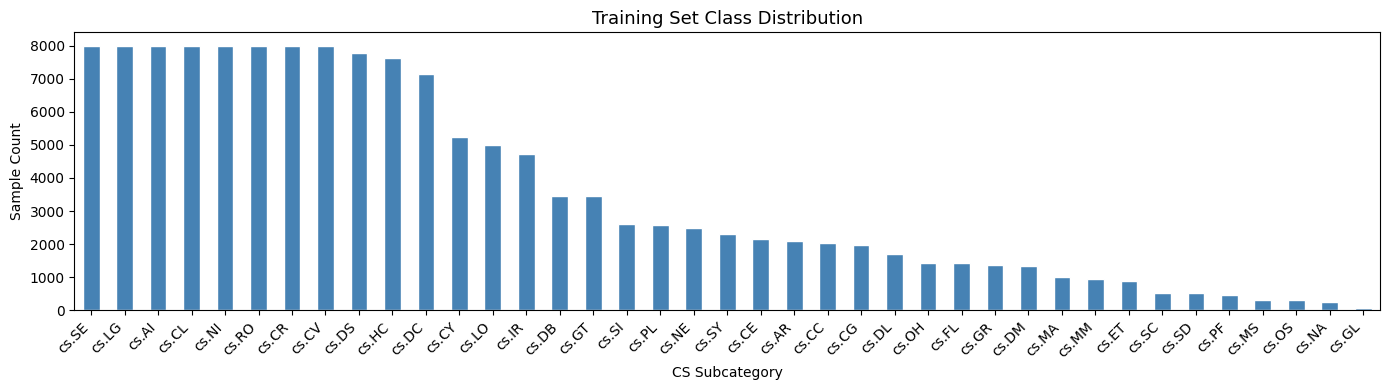

label_id
cs.SE    8000
cs.LG    8000
cs.AI    8000
cs.CL    8000
cs.NI    8000
cs.RO    8000
cs.CR    8000
cs.CV    8000
cs.DS    7773
cs.HC    7635
cs.DC    7132
cs.CY    5239
cs.LO    4984
cs.IR    4722
cs.DB    3457
cs.GT    3450
cs.SI    2611
cs.PL    2589
cs.NE    2480
cs.SY    2314
cs.CE    2153
cs.AR    2092
cs.CC    2036
cs.CG    1988
cs.DL    1691
cs.OH    1432
cs.FL    1417
cs.GR    1366
cs.DM    1338
cs.MA    1010
cs.MM     933
cs.ET     875
cs.SC     522
cs.SD     510
cs.PF     470
cs.MS     313
cs.OS     301
cs.NA     266
cs.GL      57
Name: count, dtype: int64


In [3]:
class_counts = (
    train_df['label_id']
    .map(id_to_cat)
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 4))
class_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Training Set Class Distribution', fontsize=13)
plt.xlabel('CS Subcategory')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120)
plt.show()
print(class_counts)

## 3. Text Preprocessing

In [4]:
def preprocess(text: str) -> str:
    # Removes any unnecessary characters
    text = text.lower()
    text = re.sub(r'\$[^$]*\$', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean'] = train_df['abstract'].apply(preprocess)

test_df['clean']  = test_df['abstract'].apply(preprocess)

print('\nSample text before:', train_df['abstract'].iloc[0][:120])
print('Sample text after :', train_df['clean'].iloc[0][:120])


Sample text before: Project-based learning plays a crucial role in computing education. However, its open-ended nature makes tracking projec
Sample text after : project based learning plays a crucial role in computing education however its open ended nature makes tracking project 


## 4. TF-IDF + Truncated SVD

In [ ]:
# Hyper Parameters
TFIDF_MAX_FEATURES = 5000 # Vocabulary size
SVD_N_COMPONENTS   = 500  # Latent semantic analysis dimensions
SVD_RANDOM_STATE   = 42   # Random seed of 42 for reproducibility

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(train_df['clean'])
X_test_tfidf  = tfidf.transform(test_df['clean'])
print(f'TF-IDF matrix shape - Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}')

# Truncated SVD
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=SVD_RANDOM_STATE)

X_train = svd.fit_transform(X_train_tfidf)
X_test  = svd.transform(X_test_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f'Cumulative explained variance: {explained:.2%}')
print(f'Feature matrix - Train: {X_train.shape}, Test: {X_test.shape}')

y_train = train_df['label_id'].values

TF-IDF matrix shape - Train: (139156, 5000), Test: (34790, 5000)
Cumulative explained variance: 34.34%
Feature matrix - Train: (139156, 500), Test: (34790, 500)


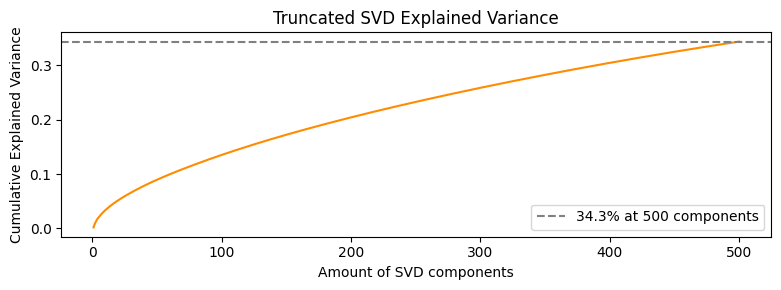

In [ ]:
cumvar = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(8, 3))
plt.plot(range(1, len(cumvar)+1), cumvar, linewidth=1.5, color='darkorange')
plt.axhline(y=explained, color='grey', linestyle='--', label=f'{explained:.1%} at {SVD_N_COMPONENTS} components')
plt.xlabel('Amount of SVD components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Truncated SVD Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Random Forest Classifier

In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Random Forest configuration:')
print(rf)

Random Forest configuration:
RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=500, n_jobs=-1, random_state=42)


## 6. Cross-Validation

In [8]:
N_FOLDS = 3
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f'Running {N_FOLDS}-fold stratified cross-validation...')
t0 = time.time()

cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

elapsed = time.time() - t0
print(f'\nCV Macro F1 scores : {cv_scores}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')
print(f'Elapsed: {elapsed/60:.1f} min')

Running 3-fold stratified cross-validation...

CV Macro F1 scores : [0.48529243 0.4896787  0.48850456]
Mean  : 0.4878
Std   : 0.0019
Elapsed: 17.8 min


## 7. Full training set

In [9]:
t0 = time.time()

rf.fit(X_train, y_train)

elapsed = time.time() - t0
print(f'Took {elapsed/60:.1f} minutes to complete.')

Took 9.6 minutes to complete.


## 8. Evaluating the training data

In [10]:
# Predictions
y_pred_train = rf.predict(X_train)

train_macro_f1 = f1_score(y_train, y_pred_train, average='macro')
print(f'Training Macro F1 : {train_macro_f1:.4f}')
print('\n Per class training')
target_names = [id_to_cat[i] for i in sorted(id_to_cat.keys())]
print(classification_report(y_train, y_pred_train, target_names=target_names))

Training Macro F1 : 0.9990

 Per class training
              precision    recall  f1-score   support

       cs.DS       1.00      1.00      1.00      7773
       cs.CC       1.00      1.00      1.00      2036
       cs.CR       1.00      1.00      1.00      8000
       cs.PF       1.00      1.00      1.00       470
       cs.CV       1.00      1.00      1.00      8000
       cs.LG       1.00      1.00      1.00      8000
       cs.SE       1.00      1.00      1.00      8000
       cs.PL       1.00      1.00      1.00      2589
       cs.AI       1.00      1.00      1.00      8000
       cs.LO       1.00      1.00      1.00      4984
       cs.DC       1.00      1.00      1.00      7132
       cs.DM       1.00      1.00      1.00      1338
       cs.NI       1.00      1.00      1.00      8000
       cs.OH       1.00      1.00      1.00      1432
       cs.HC       1.00      1.00      1.00      7635
       cs.NE       1.00      1.00      1.00      2480
       cs.MS       1.00      1.00

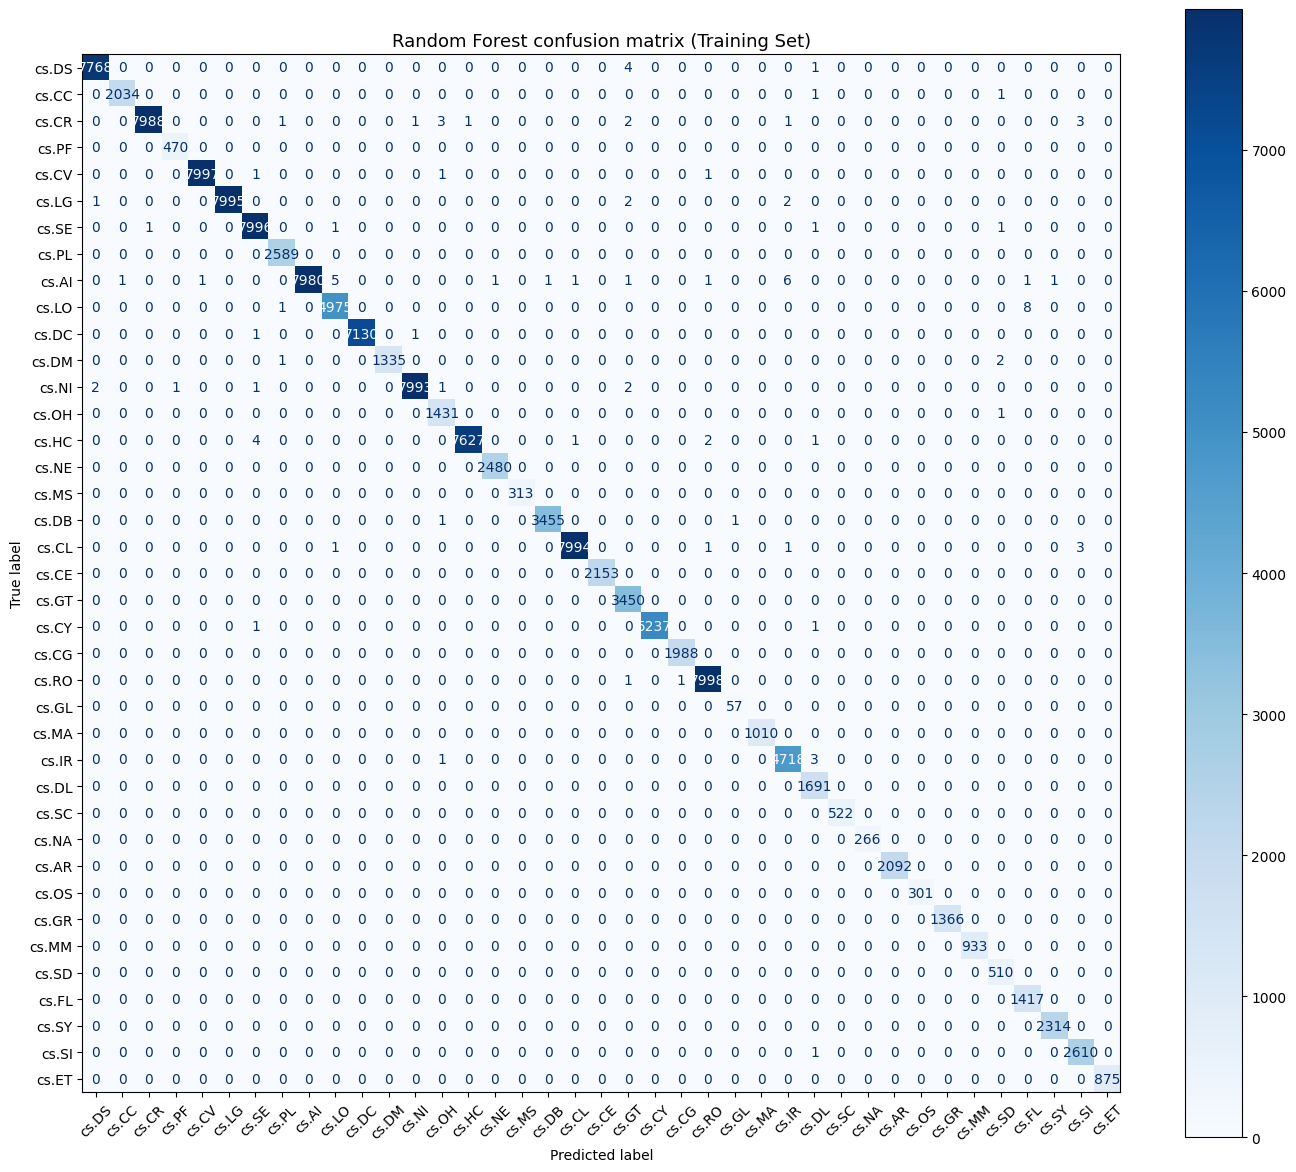

In [ ]:
# Confusion matrix for training data
cm = confusion_matrix(y_train, y_pred_train)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
ax.set_title('Random Forest confusion matrix (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis

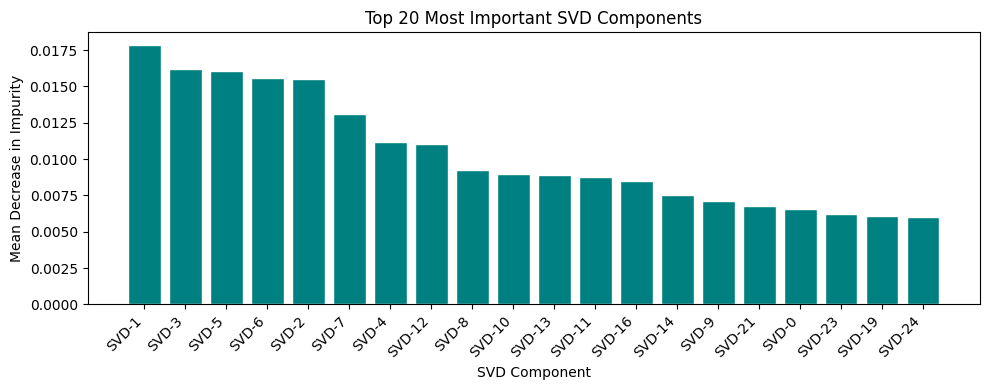

In [ ]:
# Feature Importance
importances = rf.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(10, 4))
plt.bar(range(top_k), importances[top_idx], color='teal', edgecolor='white')
plt.xticks(range(top_k), [f'SVD-{i}' for i in top_idx], rotation=45, ha='right')
plt.xlabel('SVD Component')
plt.ylabel('Mean Decrease in Impurity')
plt.title(f'Top {top_k} Most Important SVD Components')
plt.tight_layout()
plt.show()

## 10. Test predictions + kaggle submission

In [ ]:
y_pred_test = rf.predict(X_test)

# Below creates the submission file

submission = pd.DataFrame({
    'id'      : test_df['id'],
    'label_id': y_pred_test
})

submission_path = 'RF_Prediction.csv'
submission.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission.shape}')
submission.head(10)

Submission saved to: RF_Prediction.csv
Shape: (34790, 2)


,id,label_id
0,173148,38
1,29098,4
2,28211,4
3,136101,0
4,97133,14
5,87275,12
6,107208,5
7,153650,4
8,1265,20
9,99764,23


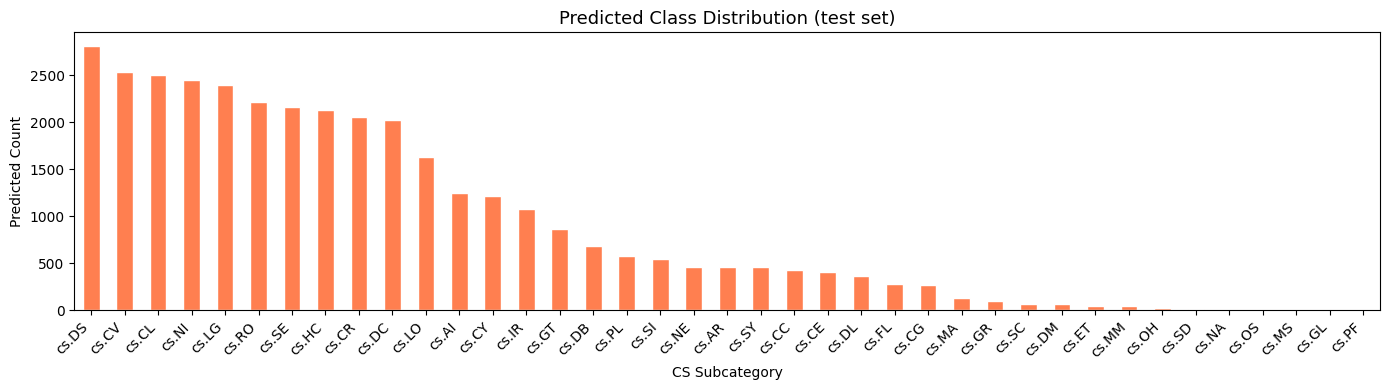

cs.DS    2816
cs.CV    2533
cs.CL    2502
cs.NI    2452
cs.LG    2398
cs.RO    2212
cs.SE    2162
cs.HC    2131
cs.CR    2058
cs.DC    2026
cs.LO    1627
cs.AI    1250
cs.CY    1219
cs.IR    1082
cs.GT     870
cs.DB     686
cs.PL     578
cs.SI     546
cs.NE     461
cs.AR     459
cs.SY     456
cs.CC     428
cs.CE     409
cs.DL     365
cs.FL     279
cs.CG     270
cs.MA     136
cs.GR      95
cs.SC      67
cs.DM      64
cs.ET      47
cs.MM      43
cs.OH      29
cs.SD      18
cs.NA       8
cs.OS       3
cs.MS       3
cs.GL       1
cs.PF       1
Name: count, dtype: int64


In [ ]:
pred_dist = (
    pd.Series(y_pred_test)
    .map(id_to_cat)
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 4))
pred_dist.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Predicted Class Distribution (test set)', fontsize=13)
plt.xlabel('CS Subcategory')
plt.ylabel('Predicted Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(pred_dist)